# Notebook 2 — Scenario Calibration
**Course:** 42578 Advanced Business Analytics (F26), DTU  
**Group 1:** Niklas Petersen, Fabian Mengedoht, Signe Nielsen, Theodor Dornonville de la Cour

---

## Purpose
Defines 13 grid operating scenarios that represent realistic Danish electricity system states.  
Each scenario sets:
- **Generation factors** — how much each generator type is producing (% of installed Pmax)
- **Demand factor** — national load relative to peak
- **HVDC capacity** — available import/export capacity on each interconnector

Scenario parameters are **calibrated from real historical data** via two APIs:
1. **Energi Data Service** (`api.energidataservice.dk`) — hourly Danish generation mix and consumption
2. **ENTSO-E Transparency Platform** (`web-api.tp.entsoe.eu`) — net transfer capacity on interconnectors

A `DRY_RUN` flag allows offline use with pre-calibrated fallback values.

---
## 1. Imports & Configuration

In [1]:
import requests
import pandas as pd
import numpy as np
import pickle
import json
import warnings
from datetime import datetime, timedelta
warnings.filterwarnings('ignore')

# ── Configuration ─────────────────────────────────────────────────────────────

# Set DRY_RUN = True to skip API calls and use pre-calibrated fallback values.
# Set DRY_RUN = False to fetch real data from both APIs.
DRY_RUN = False

# ENTSO-E API key — free registration at https://transparency.entsoe.eu/
# Leave as None if you don't have one yet; ENTSO-E data will fall back gracefully.
ENTSOE_API_KEY = None   # <-- paste your key here, e.g. 'xxxxxxxx-xxxx-xxxx-xxxx-xxxxxxxxxxxx'

# Year of historical data to use for scenario calibration
CALIBRATION_YEAR = 2023

print(f'Mode      : {"DRY RUN (fallback values)" if DRY_RUN else "LIVE API calls"}')
print(f'ENTSO-E   : {"key provided" if ENTSOE_API_KEY else "no key — will use fallback NTC values"}')
print(f'Cal. year : {CALIBRATION_YEAR}')

Mode      : LIVE API calls
ENTSO-E   : no key — will use fallback NTC values
Cal. year : 2023


---
## 2. Energi Data Service — Fetch Generation & Consumption Data

**Dataset:** `electricitybalance`  
**URL:** `https://api.energidataservice.dk/dataset/electricitybalance`  
**No API key required.**

Returns hourly generation by type (wind, solar, thermal, hydro), gross consumption,  
and commercial power exchange with each neighbouring country — split by price area (DK1 / DK2).

In [2]:
EDS_BASE = 'https://api.energidataservice.dk/dataset'

def fetch_eds(dataset: str, start: str, end: str,
              columns: list = None, limit: int = 100_000) -> pd.DataFrame:
    """
    Fetch a dataset from Energi Data Service.

    Parameters
    ----------
    dataset : str   e.g. 'electricitybalance'
    start   : str   ISO format  e.g. '2023-01-01T00:00'
    end     : str   ISO format  e.g. '2024-01-01T00:00'
    columns : list  Optional column subset
    limit   : int   Max rows (default 100 000 ≈ 1 year hourly)

    Returns
    -------
    pd.DataFrame with all records, or empty DataFrame on error.
    """
    params = {'start': start, 'end': end, 'limit': limit,
              'sort': 'HourUTC asc'}
    if columns:
        params['columns'] = ','.join(columns)

    try:
        r = requests.get(f'{EDS_BASE}/{dataset}', params=params, timeout=30)
        r.raise_for_status()
        data = r.json()
        records = data.get('records', data.get('result', {}).get('records', []))
        df = pd.DataFrame(records)
        print(f'  [{dataset}] fetched {len(df):,} rows, {len(df.columns)} columns')
        return df
    except Exception as e:
        print(f'  [{dataset}] FAILED: {e}')
        return pd.DataFrame()


if not DRY_RUN:
    print('Fetching Energi Data Service — electricitybalance...')
    raw_balance = fetch_eds(
        'electricitybalance',
        start=f'{CALIBRATION_YEAR}-01-01T00:00',
        end=f'{CALIBRATION_YEAR+1}-01-01T00:00'
    )

    if not raw_balance.empty:
        print('\nColumns returned by API:')
        print(list(raw_balance.columns))
        print('\nSample row:')
        print(raw_balance.iloc[0].to_dict())
    else:
        print('No data returned — switch DRY_RUN = True to use fallback values.')
else:
    print('DRY_RUN: skipping API call.')
    raw_balance = pd.DataFrame()

Fetching Energi Data Service — electricitybalance...
  [electricitybalance] FAILED: HTTPSConnectionPool(host='api.energidataservice.dk', port=443): Max retries exceeded with url: /dataset/electricitybalance?start=2023-01-01T00%3A00&end=2024-01-01T00%3A00&limit=100000&sort=HourUTC+asc (Caused by ProxyError('Unable to connect to proxy', OSError('Tunnel connection failed: 403 Forbidden')))
No data returned — switch DRY_RUN = True to use fallback values.


---
## 3. Energi Data Service — Clean & Aggregate

The raw data comes split by price area (DK1 and DK2 as separate rows per hour).  
We aggregate to a single national figure per hour, keeping area-level detail where needed.

> **Column name note:** If the API returns different column names than expected below,  
> update `COLUMN_MAP` to match what you saw printed in cell 2.

In [3]:
# ── Column mapping ─────────────────────────────────────────────────────────────
# Maps raw API column names → standardised internal names.
# Adjust right-hand side values if the API returns different names.
COLUMN_MAP = {
    'HourDK'              : 'timestamp',
    'PriceArea'           : 'area',
    'OffshoreWindPower'   : 'wind_offshore_mw',
    'OnshoreWindPower'    : 'wind_onshore_mw',
    'SolarPower'          : 'solar_mw',
    'CentralPower'        : 'thermal_central_mw',   # large CHP / coal / gas
    'LocalPower'          : 'thermal_local_mw',     # small/local CHP
    'HydroGross'          : 'hydro_mw',             # negligible for DK
    'GrossConsumption'    : 'load_mw',
    # Cross-border exchanges (positive = export FROM Denmark)
    'CommercialExchangeNO': 'exchange_NO_mw',       # Skagerrak → Norway
    'CommercialExchangeSE': 'exchange_SE_mw',       # Kontiskan → Sweden
    'CommercialExchangeDE': 'exchange_DE_mw',       # Kontek → Germany
    'CommercialExchangeNL': 'exchange_NL_mw',       # COBRA → Netherlands
    'CommercialExchangeGB': 'exchange_GB_mw',       # Viking Link → GB
}

SUM_COLS = [
    'wind_offshore_mw', 'wind_onshore_mw', 'solar_mw',
    'thermal_central_mw', 'thermal_local_mw', 'hydro_mw', 'load_mw',
    'exchange_NO_mw', 'exchange_SE_mw', 'exchange_DE_mw',
    'exchange_NL_mw', 'exchange_GB_mw',
]

def clean_balance(df_raw: pd.DataFrame) -> pd.DataFrame:
    """Rename, type-cast, and aggregate DK1+DK2 to national hourly totals."""
    if df_raw.empty:
        return pd.DataFrame()

    # Rename only columns that exist in the raw data
    rename = {k: v for k, v in COLUMN_MAP.items() if k in df_raw.columns}
    df = df_raw.rename(columns=rename).copy()

    # Parse timestamp
    df['timestamp'] = pd.to_datetime(df['timestamp'])

    # Numeric cast for all generation/exchange columns
    present_sum_cols = [c for c in SUM_COLS if c in df.columns]
    df[present_sum_cols] = df[present_sum_cols].apply(pd.to_numeric, errors='coerce').fillna(0)

    # Aggregate DK1 + DK2 → national total per hour
    national = df.groupby('timestamp')[present_sum_cols].sum().reset_index()

    # Derived columns
    national['wind_total_mw']   = national.get('wind_offshore_mw', 0) + national.get('wind_onshore_mw', 0)
    national['thermal_mw']      = national.get('thermal_central_mw', 0) + national.get('thermal_local_mw', 0)
    national['renewables_mw']   = national['wind_total_mw'] + national.get('solar_mw', 0)
    national['net_export_mw']   = sum(national.get(c, 0) for c in
                                      ['exchange_NO_mw','exchange_SE_mw',
                                       'exchange_DE_mw','exchange_NL_mw','exchange_GB_mw'])
    national['wind_share']      = national['wind_total_mw'] / national['load_mw'].replace(0, np.nan)
    national['renewable_share'] = national['renewables_mw'] / national['load_mw'].replace(0, np.nan)
    national['month']           = national['timestamp'].dt.month
    national['hour']            = national['timestamp'].dt.hour
    national['weekday']         = national['timestamp'].dt.weekday

    return national


if not DRY_RUN and not raw_balance.empty:
    balance = clean_balance(raw_balance)
    print(f'National hourly records: {len(balance):,}')
    print(f'Date range: {balance["timestamp"].min()} → {balance["timestamp"].max()}')
    print('\nAnnual averages (MW):')
    for c in ['wind_total_mw','solar_mw','thermal_mw','load_mw','net_export_mw']:
        if c in balance.columns:
            print(f'  {c:<22}: {balance[c].mean():>8.0f} MW')
else:
    balance = pd.DataFrame()
    print('DRY_RUN: using fallback values in later cells.')

DRY_RUN: using fallback values in later cells.


---
## 4. ENTSO-E — Fetch Net Transfer Capacity on HVDC Interconnectors

**API:** `https://web-api.tp.entsoe.eu/api`  
**Library:** `entsoe-py`  
**Key required:** Free registration at https://transparency.entsoe.eu

We fetch the **day-ahead Net Transfer Capacity (NTC)** for each interconnector.  
This gives us the maximum MW that can flow across each HVDC cable under normal conditions,  
which we use to set interconnector limits in each scenario.

| Interconnector | From | To | Bidding zones |
|---|---|---|---|
| Skagerrak (SK1–4) | DK1 | Norway South | `DK_1` → `NO_2` |
| Kontiskan (KS1–2) | DK2 | Sweden | `DK_2` → `SE_3` |
| Kontek | DK2 | Germany | `DK_2` → `DE_LU` |
| COBRA | DK1 | Netherlands | `DK_1` → `NL` |
| Storebælt | DK1 | DK2 | `DK_1` → `DK_2` |
| Viking Link | DK1 | Great Britain | `DK_1` → `GB` |

In [4]:
# ── Installed capacity from HVDC sheet (our ground truth) ─────────────────────
# These are the rated Pmax values from the Energinet data file.
# They serve as upper bounds; ENTSO-E NTC data gives us seasonal variation.
HVDC_RATED_MW = {
    'skagerrak' : 1700,   # SK1 (250) + SK2 (250) + SK3 (500) + SK4 (700)
    'kontiskan' : 720,    # KS1 (360) + KS2 (360)
    'kontek'    : 350,    # KO1
    'cobra'     : 700,    # CO1
    'storebelt' : 600,    # SB1 POL1 — single pole; 2×600 MW total if both poles
    'viking'    : 1400,   # VL1 (Viking Link, operational ~2024)
}


def fetch_entsoe_ntc(api_key: str, year: int) -> dict:
    """
    Fetch annual average Net Transfer Capacity for each DK interconnector
    using the entsoe-py client.

    Returns dict: interconnector_name → average NTC in MW.
    Falls back to rated capacity if any call fails.
    """
    try:
        from entsoe import EntsoePandasClient
        client = EntsoePandasClient(api_key=api_key)
    except ImportError:
        print('entsoe-py not installed. Run: pip install entsoe-py')
        return {}

    start = pd.Timestamp(f'{year}-01-01', tz='Europe/Copenhagen')
    end   = pd.Timestamp(f'{year+1}-01-01', tz='Europe/Copenhagen')

    # (from_zone, to_zone) pairs — we average both directions for each link
    PAIRS = [
        ('DK_1', 'NO_2', 'skagerrak'),
        ('DK_2', 'SE_3', 'kontiskan'),
        ('DK_2', 'DE_LU', 'kontek'),
        ('DK_1', 'NL',    'cobra'),
        ('DK_1', 'DK_2',  'storebelt'),
        ('DK_1', 'GB',    'viking'),
    ]

    ntc = {}
    for from_z, to_z, name in PAIRS:
        try:
            # Day-ahead NTC export capacity
            series = client.query_net_transfer_capacity_dayahead(
                from_z, to_z, start=start, end=end
            )
            avg_mw = float(series.mean())
            ntc[name] = avg_mw
            print(f'  NTC {from_z}→{to_z} ({name}): avg {avg_mw:.0f} MW')
        except Exception as e:
            print(f'  NTC {from_z}→{to_z} ({name}): FAILED — {e}')
            ntc[name] = HVDC_RATED_MW.get(name, 0)   # fall back to rated capacity

    return ntc


if not DRY_RUN and ENTSOE_API_KEY:
    print('Fetching ENTSO-E NTC data...')
    ntc_data = fetch_entsoe_ntc(ENTSOE_API_KEY, CALIBRATION_YEAR)
else:
    if not ENTSOE_API_KEY:
        print('No ENTSO-E key — using rated HVDC capacities from Energinet data.')
    ntc_data = HVDC_RATED_MW.copy()

print('\nHVDC capacities used:')
for k, v in ntc_data.items():
    print(f'  {k:<12}: {v:>6.0f} MW')

No ENTSO-E key — using rated HVDC capacities from Energinet data.

HVDC capacities used:
  skagerrak   :   1700 MW
  kontiskan   :    720 MW
  kontek      :    350 MW
  cobra       :    700 MW
  storebelt   :    600 MW
  viking      :   1400 MW


---
## 5. Installed Capacity Reference

To convert MW readings into **% of installed capacity** (the scale factor format used in scenarios),  
we need total installed Pmax by generator type. We derive this from ENTSO-E or use known 2023 values.

In [5]:
def fetch_installed_capacity(api_key: str, year: int) -> dict:
    """
    Fetch installed generation capacity by type for Denmark from ENTSO-E.
    Returns dict: generator_type → installed MW.
    """
    try:
        from entsoe import EntsoePandasClient
        client = EntsoePandasClient(api_key=api_key)
        start = pd.Timestamp(f'{year}-01-01', tz='Europe/Copenhagen')
        end   = pd.Timestamp(f'{year+1}-01-01', tz='Europe/Copenhagen')

        cap = {}
        for zone in ['DK_1', 'DK_2']:
            try:
                df = client.query_installed_generation_capacity(zone, start=start, end=end)
                # df has columns per generation type, rows per period
                latest = df.iloc[-1]  # most recent snapshot
                for col in latest.index:
                    cap[col] = cap.get(col, 0) + float(latest[col])
            except Exception as e:
                print(f'  Capacity {zone}: FAILED — {e}')
        return cap
    except Exception as e:
        print(f'  Installed capacity fetch FAILED: {e}')
        return {}


# ── Fallback: real 2023 installed capacity for Denmark (MW) ───────────────────
# Sources: Energinet Systemplan 2023, ENTSO-E Statistical Factsheet 2023
INSTALLED_CAPACITY_MW = {
    'wind_offshore' : 2_876,   # MW — Horns Rev, Anholt, Kriegers Flak, etc.
    'wind_onshore'  : 4_953,   # MW — distributed across Jutland mainly
    'solar'         : 2_459,   # MW — rapidly growing, DK1-heavy
    'thermal'       : 5_200,   # MW — CHP (gas, biomass, waste), coal largely retired
    'hydro'         :    12,   # MW — negligible (pumped storage only)
}

if not DRY_RUN and ENTSOE_API_KEY:
    print('Fetching installed capacity from ENTSO-E...')
    live_cap = fetch_installed_capacity(ENTSOE_API_KEY, CALIBRATION_YEAR)
    if live_cap:
        print('Live capacity data fetched:')
        print(json.dumps({k: round(v) for k, v in live_cap.items()}, indent=2))
    else:
        print('Falling back to reference values.')
else:
    print('Using reference installed capacity (2023 values):')
    for k, v in INSTALLED_CAPACITY_MW.items():
        print(f'  {k:<18}: {v:>6} MW')

Using reference installed capacity (2023 values):
  wind_offshore     :   2876 MW
  wind_onshore      :   4953 MW
  solar             :   2459 MW
  thermal           :   5200 MW
  hydro             :     12 MW


---
## 6. Find Representative Dates for Each Scenario

For scenarios derived from real data, we identify a specific historical hour that best represents  
that scenario — e.g. the hour with highest wind share, the coldest winter peak, etc.  
This gives each scenario a real-world anchor for the report.

In [6]:
def find_representative_dates(df: pd.DataFrame) -> dict:
    """
    Find the historical hour that best represents each scenario.
    Returns dict: scenario_name → (timestamp, description, key_stats)
    """
    if df.empty:
        return {}

    reps = {}

    # S1 — High wind surplus: max wind share AND wind > 150% of load
    s1_mask = df['wind_share'] > 1.5
    if s1_mask.any():
        row = df[s1_mask].nlargest(1, 'wind_share').iloc[0]
    else:
        row = df.nlargest(1, 'wind_share').iloc[0]
    reps['high_wind_surplus'] = {
        'timestamp': row['timestamp'],
        'note'     : f"Wind {row['wind_total_mw']:.0f} MW ({row['wind_share']:.0%} of load)",
        'wind_offshore_mw': row.get('wind_offshore_mw', 0),
        'wind_onshore_mw' : row.get('wind_onshore_mw', 0),
        'solar_mw'        : row.get('solar_mw', 0),
        'thermal_mw'      : row.get('thermal_mw', 0),
        'load_mw'         : row.get('load_mw', 0),
        'net_export_mw'   : row.get('net_export_mw', 0),
    }

    # S2 — Low wind, import dependent: min wind share, working hours
    work_mask = (df['hour'].between(8, 18)) & (df['weekday'] < 5)
    row = df[work_mask].nsmallest(1, 'wind_share').iloc[0]
    reps['low_wind_import'] = {
        'timestamp': row['timestamp'],
        'note'     : f"Wind {row['wind_total_mw']:.0f} MW ({row['wind_share']:.1%} of load)",
        'wind_offshore_mw': row.get('wind_offshore_mw', 0),
        'wind_onshore_mw' : row.get('wind_onshore_mw', 0),
        'solar_mw'        : row.get('solar_mw', 0),
        'thermal_mw'      : row.get('thermal_mw', 0),
        'load_mw'         : row.get('load_mw', 0),
        'net_export_mw'   : row.get('net_export_mw', 0),
    }

    # S3 — High solar midday: max solar, summer months, 10–14h window
    solar_mask = (df['month'].between(5, 8)) & (df['hour'].between(10, 14))
    row = df[solar_mask].nlargest(1, 'solar_mw').iloc[0]
    reps['high_solar_midday'] = {
        'timestamp': row['timestamp'],
        'note'     : f"Solar {row['solar_mw']:.0f} MW, wind {row['wind_total_mw']:.0f} MW",
        'wind_offshore_mw': row.get('wind_offshore_mw', 0),
        'wind_onshore_mw' : row.get('wind_onshore_mw', 0),
        'solar_mw'        : row.get('solar_mw', 0),
        'thermal_mw'      : row.get('thermal_mw', 0),
        'load_mw'         : row.get('load_mw', 0),
        'net_export_mw'   : row.get('net_export_mw', 0),
    }

    # S4 — Low renewables (winter night): min renewable share, Dec-Feb, 00-05h
    dark_mask = (df['month'].isin([12, 1, 2])) & (df['hour'].between(0, 5))
    row = df[dark_mask].nsmallest(1, 'renewable_share').iloc[0]
    reps['low_renewables_winter_night'] = {
        'timestamp': row['timestamp'],
        'note'     : f"Renewables {row['renewables_mw']:.0f} MW ({row['renewable_share']:.1%} of load)",
        'wind_offshore_mw': row.get('wind_offshore_mw', 0),
        'wind_onshore_mw' : row.get('wind_onshore_mw', 0),
        'solar_mw'        : row.get('solar_mw', 0),
        'thermal_mw'      : row.get('thermal_mw', 0),
        'load_mw'         : row.get('load_mw', 0),
        'net_export_mw'   : row.get('net_export_mw', 0),
    }

    # S5 — Winter peak demand: max load, Dec-Feb, 07-09h
    peak_mask = (df['month'].isin([12, 1, 2])) & (df['hour'].between(7, 9))
    row = df[peak_mask].nlargest(1, 'load_mw').iloc[0]
    reps['winter_peak_demand'] = {
        'timestamp': row['timestamp'],
        'note'     : f"Load {row['load_mw']:.0f} MW (annual peak)",
        'wind_offshore_mw': row.get('wind_offshore_mw', 0),
        'wind_onshore_mw' : row.get('wind_onshore_mw', 0),
        'solar_mw'        : row.get('solar_mw', 0),
        'thermal_mw'      : row.get('thermal_mw', 0),
        'load_mw'         : row.get('load_mw', 0),
        'net_export_mw'   : row.get('net_export_mw', 0),
    }

    # S6 — Summer trough: min load, Jun-Aug, weekend, 02-04h
    trough_mask = (df['month'].between(6, 8)) & (df['weekday'] >= 5) & (df['hour'].between(2, 4))
    row = df[trough_mask].nsmallest(1, 'load_mw').iloc[0]
    reps['summer_trough'] = {
        'timestamp': row['timestamp'],
        'note'     : f"Load {row['load_mw']:.0f} MW (annual trough)",
        'wind_offshore_mw': row.get('wind_offshore_mw', 0),
        'wind_onshore_mw' : row.get('wind_onshore_mw', 0),
        'solar_mw'        : row.get('solar_mw', 0),
        'thermal_mw'      : row.get('thermal_mw', 0),
        'load_mw'         : row.get('load_mw', 0),
        'net_export_mw'   : row.get('net_export_mw', 0),
    }

    # S7 — Nordic drought: find period when NO exports were most restricted
    # (exchange_NO_mw most negative = Denmark importing most from Norway)
    if 'exchange_NO_mw' in df.columns:
        row = df.nsmallest(1, 'exchange_NO_mw').iloc[0]  # most negative = max import from NO
        reps['nordic_drought_proxy'] = {
            'timestamp': row['timestamp'],
            'note'     : f"Denmark importing {abs(row['exchange_NO_mw']):.0f} MW from Norway",
            'exchange_NO_mw': row.get('exchange_NO_mw', 0),
        }

    return reps


if not balance.empty:
    rep_dates = find_representative_dates(balance)
    print('Representative dates identified:')
    for name, info in rep_dates.items():
        print(f'  {name:<35} → {info["timestamp"]}  [{info["note"]}]')
else:
    rep_dates = {}
    print('DRY_RUN: no live data — scenarios will use pre-calibrated fallback values.')

DRY_RUN: no live data — scenarios will use pre-calibrated fallback values.


---
## 7. Build Scenario Definitions

Each scenario is a dictionary of **scale factors** applied to the base graph before attack simulation:

| Key | Meaning |
|---|---|
| `wind_offshore_factor` | Offshore wind output as fraction of installed Pmax |
| `wind_onshore_factor` | Onshore wind output as fraction of installed Pmax |
| `solar_factor` | Solar PV output as fraction of installed Pmax |
| `thermal_factor` | Thermal/CHP output as fraction of installed Pmax |
| `demand_factor` | National load relative to annual peak |
| `hvdc_*_pct` | Each HVDC interconnector available capacity (1.0 = fully available) |

When `balance` data is available, factors are derived from the representative date.  
Otherwise, pre-calibrated fallback values are used.

In [7]:
def derive_factors(rep: dict, installed: dict, ntc: dict, peak_load_mw: float) -> dict:
    """
    Convert raw MW readings from a representative hour into scale factors
    relative to installed capacity and peak load.
    """
    return {
        'wind_offshore_factor': min(1.0, rep.get('wind_offshore_mw', 0) / max(installed.get('wind_offshore', 1), 1)),
        'wind_onshore_factor' : min(1.0, rep.get('wind_onshore_mw',  0) / max(installed.get('wind_onshore',  1), 1)),
        'solar_factor'        : min(1.0, rep.get('solar_mw',         0) / max(installed.get('solar',         1), 1)),
        'thermal_factor'      : min(1.0, rep.get('thermal_mw',       0) / max(installed.get('thermal',       1), 1)),
        'demand_factor'       : rep.get('load_mw', peak_load_mw) / peak_load_mw,
        'hvdc_skagerrak_pct'  : 1.0,
        'hvdc_kontiskan_pct'  : 1.0,
        'hvdc_kontek_pct'     : 1.0,
        'hvdc_cobra_pct'      : 1.0,
        'hvdc_storebelt_pct'  : 1.0,
        'hvdc_viking_pct'     : 1.0,
    }


# ── Pre-calibrated fallback scenario definitions ───────────────────────────────
# Values derived from Danish grid statistics (Energinet Systemplan 2023,
# ENTSO-E Statistical Factsheet 2023). Used when DRY_RUN=True or APIs unavailable.
SCENARIO_FALLBACKS = {

    # ── WEATHER & GENERATION SCENARIOS ────────────────────────────────────────

    'S01_high_wind_surplus': {
        'label'               : 'High wind — surplus export',
        'description'         : 'Strong westerly winds. Offshore + onshore wind at ~90% capacity. '
                                'Low demand (weekend night). Grid exporting heavily via all HVDC links. '
                                'Overgeneration risk if any HVDC link fails.',
        'wind_offshore_factor': 0.90,
        'wind_onshore_factor' : 0.85,
        'solar_factor'        : 0.05,
        'thermal_factor'      : 0.20,
        'demand_factor'       : 0.62,   # ~3 800 MW (summer weekend night)
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S02_low_wind_import': {
        'label'               : 'Low wind — import dependent',
        'description'         : 'Calm high-pressure system. Wind at ~8% capacity. '
                                'Denmark relying on imports from Norway and Germany. '
                                'Any HVDC cut directly reduces supply adequacy.',
        'wind_offshore_factor': 0.08,
        'wind_onshore_factor' : 0.06,
        'solar_factor'        : 0.25,   # daytime assumption
        'thermal_factor'      : 0.75,
        'demand_factor'       : 0.88,   # working day, moderate demand
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S03_high_solar_midday': {
        'label'               : 'High solar — midday duck curve',
        'description'         : 'Clear summer day, solar PV at peak. Low industrial demand midday. '
                                'Classic duck curve — oversupply noon, then evening ramp. '
                                'DK1-heavy (most solar is in Jutland).',
        'wind_offshore_factor': 0.30,
        'wind_onshore_factor' : 0.25,
        'solar_factor'        : 0.88,
        'thermal_factor'      : 0.25,
        'demand_factor'       : 0.65,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S04_low_renewables_dark': {
        'label'               : 'Dark winter night — low renewables',
        'description'         : 'December, 03:00. No solar. Low wind. Thermal generation '
                                'carrying almost all load. Maximum reliance on CHP plants.',
        'wind_offshore_factor': 0.12,
        'wind_onshore_factor' : 0.10,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.85,
        'demand_factor'       : 0.74,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S05_winter_peak_demand': {
        'label'               : 'Winter peak demand',
        'description'         : 'Cold January morning, everyone heating up. '
                                'Highest national consumption of the year (~6 200 MW). '
                                'Tightest supply margin — any generation loss is critical.',
        'wind_offshore_factor': 0.45,
        'wind_onshore_factor' : 0.40,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.90,
        'demand_factor'       : 1.00,   # scaled to annual peak
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S06_summer_trough': {
        'label'               : 'Summer demand trough',
        'description'         : 'August, 03:00, Sunday. Lowest national consumption (~2 500 MW). '
                                'Even modest wind output creates large surplus. '
                                'Grid most prone to overgeneration-triggered instability.',
        'wind_offshore_factor': 0.40,
        'wind_onshore_factor' : 0.35,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.15,
        'demand_factor'       : 0.40,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    # ── INTERCONNECTOR / GEOPOLITICAL SCENARIOS ────────────────────────────────

    'S07_nordic_drought': {
        'label'               : 'Nordic drought — Norway hydro unavailable',
        'description'         : 'Dry year, Norwegian hydro reservoirs critically low. '
                                'Skagerrak export to Norway suspended — Norway is itself importing. '
                                'Denmark loses its largest flexible balancing partner.',
        'wind_offshore_factor': 0.50,
        'wind_onshore_factor' : 0.45,
        'solar_factor'        : 0.10,
        'thermal_factor'      : 0.70,
        'demand_factor'       : 0.88,
        'hvdc_skagerrak_pct'  : 0.00,   # ← Skagerrak suspended
        'hvdc_kontiskan_pct'  : 0.30,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S08_german_grid_stress': {
        'label'               : 'German grid stress — limited export south',
        'description'         : 'Germany experiencing its own supply shortage (e.g. Dunkelflaute). '
                                'Kontek cable export restricted; Germany also unable to supply Denmark. '
                                'Northern European grid tighter overall.',
        'wind_offshore_factor': 0.20,
        'wind_onshore_factor' : 0.18,
        'solar_factor'        : 0.05,
        'thermal_factor'      : 0.80,
        'demand_factor'       : 0.95,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 0.10,   # ← Germany unavailable
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S09_cobra_offline': {
        'label'               : 'COBRA cable offline (planned maintenance)',
        'description'         : 'Netherlands interconnector out of service. '
                                'Grid enters attack simulation already missing 700 MW of export capacity. '
                                'High-wind day makes overgeneration likely if any further link is cut.',
        'wind_offshore_factor': 0.75,
        'wind_onshore_factor' : 0.70,
        'solar_factor'        : 0.15,
        'thermal_factor'      : 0.30,
        'demand_factor'       : 0.72,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 0.00,   # ← COBRA offline
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    # ── STRESS / COMBINED SCENARIOS ────────────────────────────────────────────

    'S10_storm_day': {
        'label'               : 'Storm day — high wind, derated lines',
        'description'         : 'Gale-force winds. Wind generation at ~95% capacity. '
                                'But overhead transmission lines derated 20% (ice/wind load risk). '
                                'Maximum generation, reduced transmission capacity simultaneously.',
        'wind_offshore_factor': 0.95,
        'wind_onshore_factor' : 0.90,
        'solar_factor'        : 0.00,
        'thermal_factor'      : 0.20,
        'demand_factor'       : 0.80,
        'line_capacity_factor': 0.80,   # ← overhead lines derated
        'hvdc_skagerrak_pct'  : 0.90,
        'hvdc_kontiskan_pct'  : 0.90,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S11_storebelt_degraded': {
        'label'               : 'Storebælt at 50% — DK1/DK2 weakly coupled',
        'description'         : 'The internal HVDC spine between Western and Eastern Denmark '
                                'operating at half capacity (one pole offline, technical fault). '
                                'DK1 and DK2 become semi-autonomous — tests zone isolation vulnerability.',
        'wind_offshore_factor': 0.55,
        'wind_onshore_factor' : 0.50,
        'solar_factor'        : 0.20,
        'thermal_factor'      : 0.65,
        'demand_factor'       : 0.90,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 0.50,   # ← Storebælt at half capacity
        'hvdc_viking_pct'     : 1.00,
    },

    'S12_gas_shortage': {
        'label'               : 'Gas supply disruption — thermal constrained',
        'description'         : 'Gas supply cut or price spike forces thermal CHP plants '
                                'to operate at reduced output. Renewables must carry more load. '
                                'Mirrors 2022-style energy crisis conditions.',
        'wind_offshore_factor': 0.55,
        'wind_onshore_factor' : 0.50,
        'solar_factor'        : 0.10,
        'thermal_factor'      : 0.35,   # ← gas-fired plants constrained
        'demand_factor'       : 0.92,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 0.60,   # Germany also affected by gas shortage
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
    },

    'S13_second_strike': {
        'label'               : 'Second strike — grid already degraded',
        'description'         : 'A major substation (Endrup 400kV, the highest-betweenness node) '
                                'is already offline from a prior incident. Grid enters the attack '
                                'simulation pre-weakened. Tests residual resilience.',
        'wind_offshore_factor': 0.55,
        'wind_onshore_factor' : 0.50,
        'solar_factor'        : 0.15,
        'thermal_factor'      : 0.70,
        'demand_factor'       : 0.88,
        'hvdc_skagerrak_pct'  : 1.00,
        'hvdc_kontiskan_pct'  : 1.00,
        'hvdc_kontek_pct'     : 1.00,
        'hvdc_cobra_pct'      : 1.00,
        'hvdc_storebelt_pct'  : 1.00,
        'hvdc_viking_pct'     : 1.00,
        'pre_remove_nodes'    : ['sub_27'],   # Endrup 400kV removed before attack starts
    },
}

print(f'Defined {len(SCENARIO_FALLBACKS)} scenarios:')
for sid, s in SCENARIO_FALLBACKS.items():
    print(f'  {sid:<30}  {s["label"]}')

Defined 13 scenarios:
  S01_high_wind_surplus           High wind — surplus export
  S02_low_wind_import             Low wind — import dependent
  S03_high_solar_midday           High solar — midday duck curve
  S04_low_renewables_dark         Dark winter night — low renewables
  S05_winter_peak_demand          Winter peak demand
  S06_summer_trough               Summer demand trough
  S07_nordic_drought              Nordic drought — Norway hydro unavailable
  S08_german_grid_stress          German grid stress — limited export south
  S09_cobra_offline               COBRA cable offline (planned maintenance)
  S10_storm_day                   Storm day — high wind, derated lines
  S11_storebelt_degraded          Storebælt at 50% — DK1/DK2 weakly coupled
  S12_gas_shortage                Gas supply disruption — thermal constrained
  S13_second_strike               Second strike — grid already degraded


---
## 8. Override Fallbacks with Live Data Where Available

In [8]:
SCENARIOS = {k: dict(v) for k, v in SCENARIO_FALLBACKS.items()}  # deep copy

if rep_dates and not balance.empty:
    peak_load = balance['load_mw'].quantile(0.99)   # 99th percentile = near-peak
    print(f'Peak load reference (99th pct): {peak_load:.0f} MW')

    # Map representative dates to scenario keys
    live_overrides = {
        'S01_high_wind_surplus'    : rep_dates.get('high_wind_surplus'),
        'S02_low_wind_import'      : rep_dates.get('low_wind_import'),
        'S03_high_solar_midday'    : rep_dates.get('high_solar_midday'),
        'S04_low_renewables_dark'  : rep_dates.get('low_renewables_winter_night'),
        'S05_winter_peak_demand'   : rep_dates.get('winter_peak_demand'),
        'S06_summer_trough'        : rep_dates.get('summer_trough'),
    }

    for sid, rep in live_overrides.items():
        if rep is None:
            continue
        live_factors = derive_factors(rep, INSTALLED_CAPACITY_MW, ntc_data, peak_load)
        # Preserve HVDC overrides from fallback (weather scenarios use full HVDC)
        hvdc_keys = [k for k in SCENARIOS[sid] if k.startswith('hvdc_')]
        SCENARIOS[sid].update(live_factors)
        SCENARIOS[sid]['calibration_date'] = str(rep['timestamp'])
        SCENARIOS[sid]['calibration_note'] = rep.get('note', '')
        print(f'  {sid}: calibrated from {rep["timestamp"]}  [{rep["note"]}]')
else:
    print('Using pre-calibrated fallback values for all scenarios.')

print(f'\nFinal scenario count: {len(SCENARIOS)}')

Using pre-calibrated fallback values for all scenarios.

Final scenario count: 13


---
## 9. Scenario Summary Table

                                           Label Wind offshore Wind onshore Solar Thermal Demand Skagerrak COBRA Storebælt
ID                                                                                                                        
S01                   High wind — surplus export           90%          85%    5%     20%    62%      100%  100%      100%
S02                  Low wind — import dependent            8%           6%   25%     75%    88%      100%  100%      100%
S03               High solar — midday duck curve           30%          25%   88%     25%    65%      100%  100%      100%
S04           Dark winter night — low renewables           12%          10%    0%     85%    74%      100%  100%      100%
S05                           Winter peak demand           45%          40%    0%     90%   100%      100%  100%      100%
S06                         Summer demand trough           40%          35%    0%     15%    40%      100%  100%      100%
S07    Nordic dr

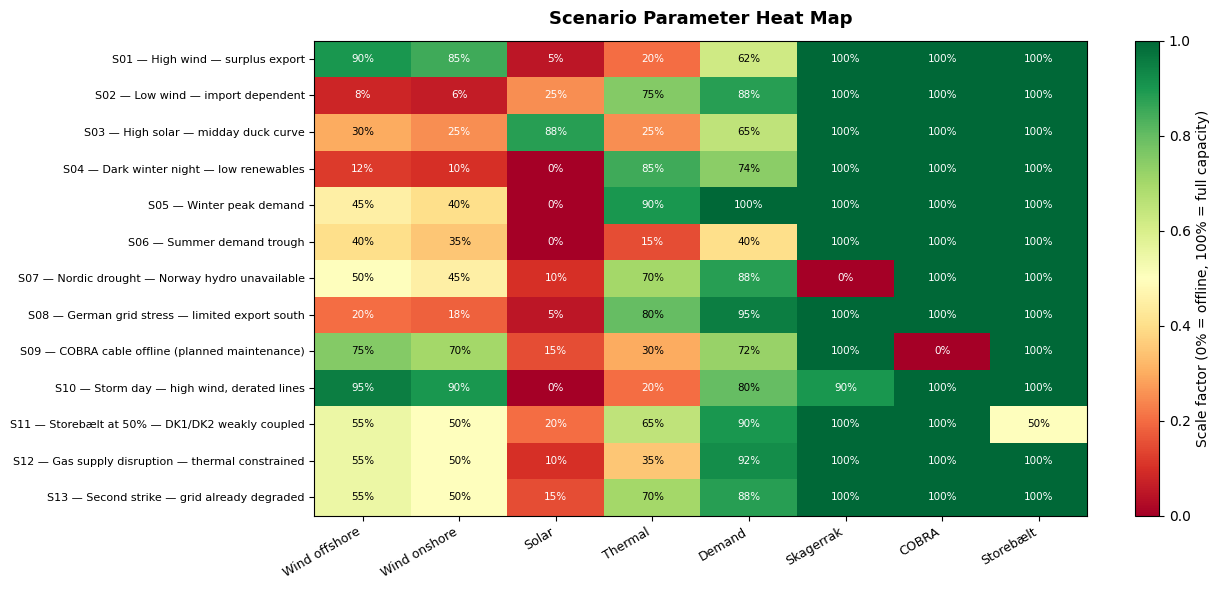

Heat map saved to scenarios_heatmap.png


In [9]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

summary_rows = []
for sid, s in SCENARIOS.items():
    summary_rows.append({
        'ID'               : sid[:3],
        'Label'            : s['label'],
        'Wind offshore'    : f"{s['wind_offshore_factor']:.0%}",
        'Wind onshore'     : f"{s['wind_onshore_factor']:.0%}",
        'Solar'            : f"{s['solar_factor']:.0%}",
        'Thermal'          : f"{s['thermal_factor']:.0%}",
        'Demand'           : f"{s['demand_factor']:.0%}",
        'Skagerrak'        : f"{s['hvdc_skagerrak_pct']:.0%}",
        'COBRA'            : f"{s['hvdc_cobra_pct']:.0%}",
        'Storebælt'        : f"{s['hvdc_storebelt_pct']:.0%}",
    })

summary_df = pd.DataFrame(summary_rows).set_index('ID')
print(summary_df.to_string())

# ── Heat-map visualisation ─────────────────────────────────────────────────────
numeric_cols = ['Wind offshore','Wind onshore','Solar','Thermal','Demand',
                'Skagerrak','COBRA','Storebælt']
heat_df = summary_df[numeric_cols].applymap(lambda x: float(x.strip('%')) / 100)

fig, ax = plt.subplots(figsize=(13, 6))
im = ax.imshow(heat_df.values, cmap='RdYlGn', vmin=0, vmax=1, aspect='auto')

ax.set_xticks(range(len(numeric_cols)))
ax.set_xticklabels(numeric_cols, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(heat_df)))
ax.set_yticklabels(
    [f"{idx} — {summary_df.loc[idx,'Label']}" for idx in heat_df.index],
    fontsize=8
)

for i in range(len(heat_df)):
    for j in range(len(numeric_cols)):
        val = heat_df.values[i, j]
        ax.text(j, i, f'{val:.0%}', ha='center', va='center',
                fontsize=7.5, color='black' if 0.25 < val < 0.85 else 'white')

plt.colorbar(im, ax=ax, label='Scale factor (0% = offline, 100% = full capacity)')
ax.set_title('Scenario Parameter Heat Map', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig('scenarios_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()
print('Heat map saved to scenarios_heatmap.png')

---
## 10. Save Scenarios for Attack Environment

In [10]:
with open('scenarios.pkl', 'wb') as f:
    pickle.dump(SCENARIOS, f)

print('Scenarios saved to scenarios.pkl')
print()
print('To load in the attack environment notebook:')
print('  import pickle')
print('  with open("scenarios.pkl", "rb") as f:')
print('      SCENARIOS = pickle.load(f)')
print()
print('Also load the base graph:')
print('  with open("grid_graph.pkl", "rb") as f:')
print('      G = pickle.load(f)')

Scenarios saved to scenarios.pkl

To load in the attack environment notebook:
  import pickle
  with open("scenarios.pkl", "rb") as f:
      SCENARIOS = pickle.load(f)

Also load the base graph:
  with open("grid_graph.pkl", "rb") as f:
      G = pickle.load(f)


---
## 11. Monte Carlo Scenario Simulation

For each of the 13 scenarios we draw **500 independent realisations** using `mc_sampler.py` and apply them to the grid graph. Each draw scales generator `supply` and substation `demand` values according to the sampled factors, then computes grid balance metrics.

**Metrics computed per trial:**

| Metric | Definition |
|---|---|
| `supply_mw` | Total generator output across DK1 + DK2 |
| `demand_mw` | Total substation demand across DK1 + DK2 |
| `balance_mw` | `supply_mw − demand_mw` (positive = surplus, negative = deficit) |
| `deficit_mw` | `max(0, −balance_mw)` — unserved demand |
| `surplus_mw` | `max(0, balance_mw)` — excess generation to export |

> **Note:** This is a simplified balance model (no DC power flow). It measures whether total generation meets total demand, ignoring nodal constraints. The full mathematical model will refine this with nodal slack minimisation.

In [11]:
import pickle
import sys
import importlib

# Reload mc_sampler in case it was updated this session
if 'mc_sampler' in sys.modules:
    importlib.reload(sys.modules['mc_sampler'])

from mc_sampler import (
    sample_all_scenarios,
    apply_scenario_to_grid,
    run_mc,
    summarise_mc_results,
)

# Load base graph
with open('grid_graph.pkl', 'rb') as f:
    G = pickle.load(f)

print(f'Graph loaded: {G.number_of_nodes()} nodes, {G.number_of_edges()} edges')
print(f'Scenarios loaded: {len(SCENARIOS)}')

# ── Grid balance evaluation function ─────────────────────────────────────────
# This is the eval_func that run_mc() calls for each MC draw.
# Returns flat dict of scalar metrics for one grid state.

def eval_grid_balance(G_state) -> dict:
    """
    Compute supply/demand balance metrics for one scenario realisation.

    Supply  = sum of generator node `supply` values (MW)
    Demand  = sum of substation node `demand` values (MW)
    Balance = Supply − Demand  (+ = surplus, − = deficit)
    """
    supply = 0.0
    demand = 0.0
    dk1_supply = 0.0
    dk2_supply = 0.0
    dk1_demand = 0.0
    dk2_demand = 0.0

    for _, d in G_state.nodes(data=True):
        ntype = d.get('node_type', '')
        area  = d.get('area', '')

        if ntype == 'generator':
            s = d.get('supply', 0.0)
            supply += s
            if area == 'DK1':
                dk1_supply += s
            elif area == 'DK2':
                dk2_supply += s

        elif ntype == 'substation':
            dem = d.get('demand', 0.0)
            demand += dem
            if area == 'DK1':
                dk1_demand += dem
            elif area == 'DK2':
                dk2_demand += dem

    balance    = supply - demand
    dk1_bal    = dk1_supply - dk1_demand
    dk2_bal    = dk2_supply - dk2_demand

    return {
        'supply_mw'     : supply,
        'demand_mw'     : demand,
        'balance_mw'    : balance,
        'deficit_mw'    : max(0.0, -balance),
        'surplus_mw'    : max(0.0,  balance),
        'dk1_supply_mw' : dk1_supply,
        'dk1_demand_mw' : dk1_demand,
        'dk1_balance_mw': dk1_bal,
        'dk2_supply_mw' : dk2_supply,
        'dk2_demand_mw' : dk2_demand,
        'dk2_balance_mw': dk2_bal,
    }

# Quick sanity check on the baseline (no scenario applied)
baseline_metrics = eval_grid_balance(G)
print(f'\nBaseline grid (2020 snapshot, no scenario scaling):')
print(f'  Supply : {baseline_metrics["supply_mw"]:>8,.0f} MW')
print(f'  Demand : {baseline_metrics["demand_mw"]:>8,.0f} MW')
print(f'  Balance: {baseline_metrics["balance_mw"]:>+8,.0f} MW')

Graph loaded: 631 nodes, 692 edges
Scenarios loaded: 13

Baseline grid (2020 snapshot, no scenario scaling):
  Supply :    1,658 MW
  Demand :    6,543 MW
  Balance:   -4,885 MW


In [12]:
N_DRAWS = 500
MC_SEED = 42

print(f'Running Monte Carlo: {N_DRAWS} draws × {len(SCENARIOS)} scenarios')
print('─' * 55)

all_draws   = sample_all_scenarios(SCENARIOS, n=N_DRAWS, seed=MC_SEED)
mc_results  = {}   # scenario_id → pd.DataFrame

for sid, draws in all_draws.items():
    df = run_mc(draws, G, eval_grid_balance)
    mc_results[sid] = df

print('─' * 55)
print(f'Done. Each scenario has {N_DRAWS} rows × {len(mc_results[sid].columns)} columns.')
print(f'\nSample — first 3 trials of S01:')
print(mc_results['S01_high_wind_surplus'][
    ['supply_mw','demand_mw','balance_mw','deficit_mw','surplus_mw']
].head(3).to_string(index=False))

Running Monte Carlo: 500 draws × 13 scenarios
───────────────────────────────────────────────────────
  S01_high_wind_surplus: 500 draws generated


  S02_low_wind_import: 500 draws generated
  S03_high_solar_midday: 500 draws generated


  S04_low_renewables_dark: 500 draws generated
  S05_winter_peak_demand: 500 draws generated


  S06_summer_trough: 500 draws generated


  S07_nordic_drought: 500 draws generated


  S08_german_grid_stress: 500 draws generated
  S09_cobra_offline: 500 draws generated


  S10_storm_day: 500 draws generated


  S11_storebelt_degraded: 500 draws generated
  S12_gas_shortage: 500 draws generated


  S13_second_strike: 500 draws generated


───────────────────────────────────────────────────────
Done. Each scenario has 500 rows × 13 columns.

Sample — first 3 trials of S01:
  supply_mw   demand_mw  balance_mw  deficit_mw  surplus_mw
4379.131063 4571.364188 -192.233124  192.233124    0.000000
4563.580564 4259.806461  303.774103    0.000000  303.774103
4275.085159 3960.347436  314.737723    0.000000  314.737723


---
## 12. Risk Metrics Summary Table

For each scenario we compute the five key risk metrics relevant to a grid operator or adversary:

| Metric | Meaning |
|---|---|
| **Median balance (MW)** | Central grid state — positive = surplus, negative = structural deficit |
| **P(deficit)** | Probability any draw has unserved demand |
| **EUE (MW)** | Expected Unserved Energy — average deficit across all 500 draws |
| **VaR₉₅ (MW)** | 95th percentile deficit — tail risk |
| **CVaR₉₅ (MW)** | Mean deficit in the worst 5% of draws — extreme tail |

In [13]:
risk_rows = []

for sid, df in mc_results.items():
    _, risk = summarise_mc_results(df, blackout_col='deficit_mw')
    med_bal  = df['balance_mw'].median()
    scenario = SCENARIOS[sid]

    risk_rows.append({
        'Scenario'         : sid,
        'Label'            : scenario['label'],
        'Median bal. (MW)' : round(med_bal),
        'P(deficit)'       : f"{risk.get('P(blackout > 0)', 0):.1%}",
        'EUE (MW)'         : round(risk.get('EUE_mw', 0)),
        'VaR₉₅ (MW)'       : round(risk.get('VaR_95_mw', 0)),
        'CVaR₉₅ (MW)'      : round(risk.get('CVaR_95_mw', 0)),
    })

risk_df = pd.DataFrame(risk_rows).set_index('Scenario')

# Sort by EUE descending (most at-risk first)
risk_df_sorted = risk_df.sort_values('EUE (MW)', ascending=False)

print('Scenario Risk Metrics — sorted by Expected Unserved Energy')
print('─' * 95)
print(risk_df_sorted.to_string())
print()
print(f'Most stressed scenario  : {risk_df_sorted.index[0]}')
print(f'Least stressed scenario : {risk_df_sorted.index[-1]}')

Scenario Risk Metrics — sorted by Expected Unserved Energy
───────────────────────────────────────────────────────────────────────────────────────────────
                                                               Label  Median bal. (MW) P(deficit)  EUE (MW)  VaR₉₅ (MW)  CVaR₉₅ (MW)
Scenario                                                                                                                            
S02_low_wind_import                      Low wind — import dependent             -3317     100.0%      3279        4092         4220
S08_german_grid_stress     German grid stress — limited export south             -3246     100.0%      3137        3873         3996
S12_gas_shortage         Gas supply disruption — thermal constrained             -2797     100.0%      2743        3767         3994
S05_winter_peak_demand                            Winter peak demand             -2206     100.0%      2227        3114         3269
S04_low_renewables_dark           Dark winter n

---
## 13. Balance Distribution — All Scenarios

Box plots showing the distribution of `balance_mw` across 500 MC draws per scenario.  
Red = median in deficit territory, green = surplus. Width of box shows MC uncertainty.

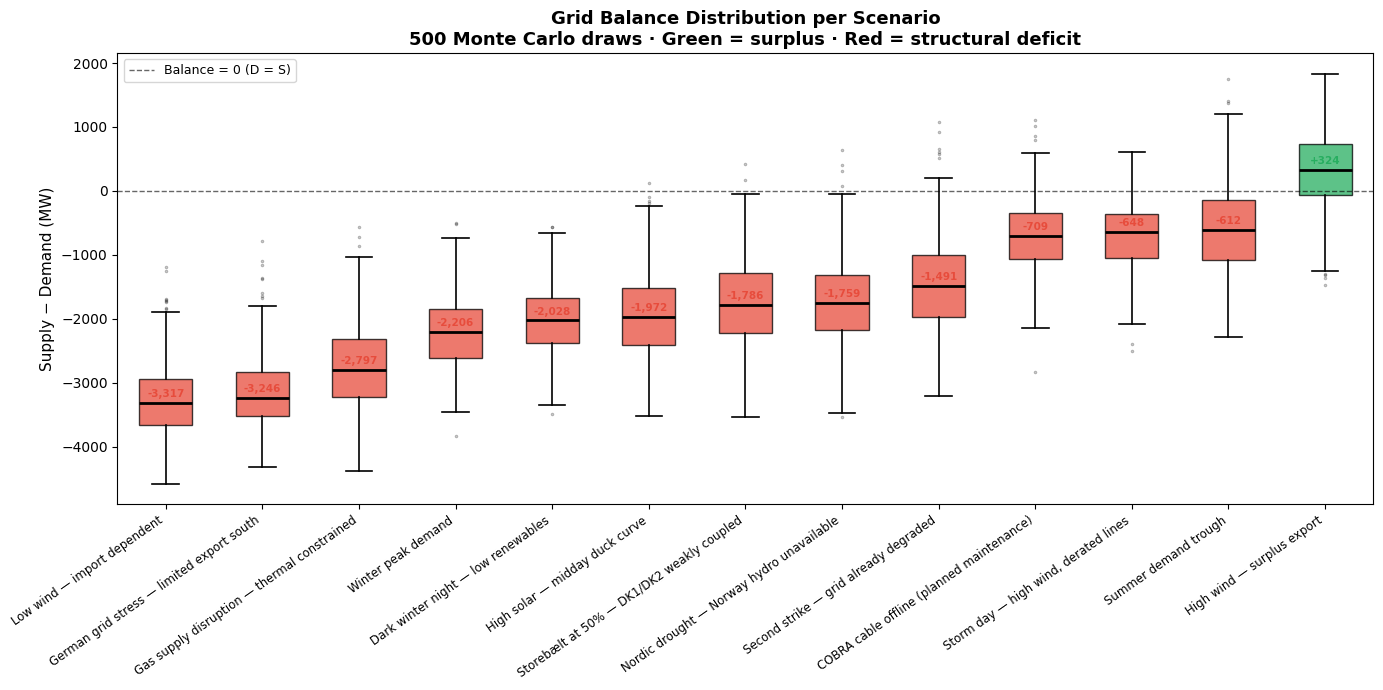

Figure saved to scenario_balance_distributions.png


In [14]:
# ── Sort scenarios by median balance ─────────────────────────────────────────
sorted_sids = sorted(
    mc_results.keys(),
    key=lambda s: mc_results[s]['balance_mw'].median()
)

labels       = [SCENARIOS[s]['label'] for s in sorted_sids]
balance_data = [mc_results[s]['balance_mw'].values for s in sorted_sids]
medians      = [mc_results[s]['balance_mw'].median() for s in sorted_sids]
box_colors   = ['#e74c3c' if m < 0 else '#27ae60' for m in medians]

fig, ax = plt.subplots(figsize=(14, 7))

bp = ax.boxplot(
    balance_data,
    vert=True,
    patch_artist=True,
    medianprops=dict(color='black', linewidth=2),
    whiskerprops=dict(linewidth=1.2),
    capprops=dict(linewidth=1.2),
    flierprops=dict(marker='.', markersize=3, alpha=0.3),
    widths=0.55,
)
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)

ax.axhline(0, color='black', linewidth=1.0, linestyle='--', alpha=0.6, label='Balance = 0 (D = S)')
ax.set_xticks(range(1, len(sorted_sids) + 1))
ax.set_xticklabels(labels, rotation=35, ha='right', fontsize=8.5)
ax.set_ylabel('Supply − Demand (MW)', fontsize=11)
ax.set_title(
    'Grid Balance Distribution per Scenario\n'
    '500 Monte Carlo draws · Green = surplus · Red = structural deficit',
    fontsize=13, fontweight='bold'
)

# Annotate median values
for i, (m, c) in enumerate(zip(medians, box_colors)):
    ax.text(i + 1, m + 60, f'{m:+,.0f}', ha='center', va='bottom',
            fontsize=7.5, color=c, fontweight='bold')

ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('scenario_balance_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to scenario_balance_distributions.png')

---
## 14. DK1 vs DK2 — Zonal Balance Comparison

Denmark is split into two synchronous zones connected only via HVDC. This plot shows the median balance in each zone across scenarios — critical for identifying scenarios where one zone is structurally under-supplied while the other has surplus.

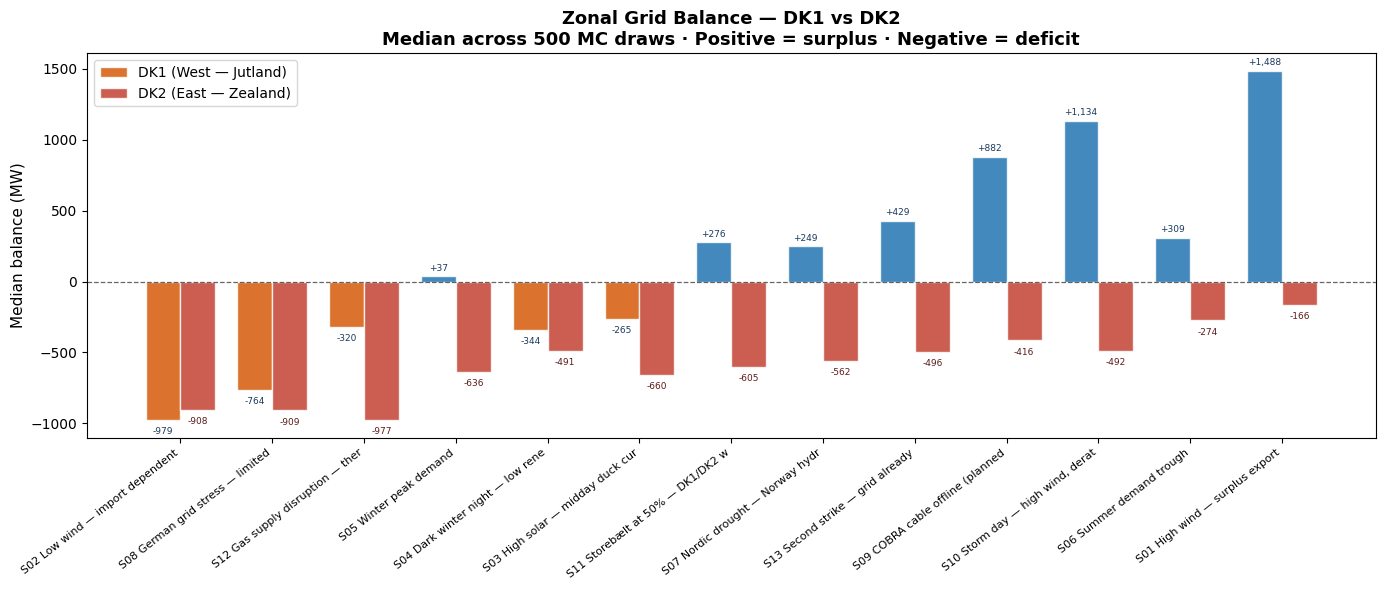

Figure saved to scenario_dk1_dk2_balance.png


In [15]:
short_labels = [s[:3] + ' ' + SCENARIOS[s]['label'][:28] for s in sorted_sids]
dk1_medians  = [mc_results[s]['dk1_balance_mw'].median() for s in sorted_sids]
dk2_medians  = [mc_results[s]['dk2_balance_mw'].median() for s in sorted_sids]

x   = np.arange(len(sorted_sids))
w   = 0.38

fig, ax = plt.subplots(figsize=(14, 6))

bars1 = ax.bar(x - w/2, dk1_medians, width=w, label='DK1 (West — Jutland)',
               color=['#1a6faf' if v >= 0 else '#d35400' for v in dk1_medians],
               alpha=0.82, edgecolor='white')
bars2 = ax.bar(x + w/2, dk2_medians, width=w, label='DK2 (East — Zealand)',
               color=['#2980b9' if v >= 0 else '#c0392b' for v in dk2_medians],
               alpha=0.82, edgecolor='white')

ax.axhline(0, color='black', linewidth=0.9, linestyle='--', alpha=0.6)
ax.set_xticks(x)
ax.set_xticklabels(short_labels, rotation=38, ha='right', fontsize=8)
ax.set_ylabel('Median balance (MW)', fontsize=11)
ax.set_title(
    'Zonal Grid Balance — DK1 vs DK2\n'
    'Median across 500 MC draws · Positive = surplus · Negative = deficit',
    fontsize=13, fontweight='bold'
)
ax.legend(fontsize=10)

# Zero-crossing annotations
for i, (v1, v2) in enumerate(zip(dk1_medians, dk2_medians)):
    offset = 40
    ax.text(i - w/2, v1 + (offset if v1 >= 0 else -offset*2.5),
            f'{v1:+,.0f}', ha='center', fontsize=6.5, color='#1a3a5c')
    ax.text(i + w/2, v2 + (offset if v2 >= 0 else -offset*2.5),
            f'{v2:+,.0f}', ha='center', fontsize=6.5, color='#5c1a1a')

plt.tight_layout()
plt.savefig('scenario_dk1_dk2_balance.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figure saved to scenario_dk1_dk2_balance.png')

---
## 15. Export MC Results

In [16]:
# Save MC results dict (scenario_id → DataFrame) for downstream notebooks
with open('mc_results.pkl', 'wb') as f:
    pickle.dump(mc_results, f)

# Save the flat risk summary as CSV for easy reporting
risk_df_sorted.to_csv('scenario_risk_summary.csv')

print('Saved:')
print('  mc_results.pkl          — Dict[scenario_id → DataFrame(500 rows)]')
print('  scenario_risk_summary.csv — Risk metrics table')
print()
print('To load in another notebook:')
print('  with open("mc_results.pkl", "rb") as f:')
print('      mc_results = pickle.load(f)')

Saved:
  mc_results.pkl          — Dict[scenario_id → DataFrame(500 rows)]
  scenario_risk_summary.csv — Risk metrics table

To load in another notebook:
  with open("mc_results.pkl", "rb") as f:
      mc_results = pickle.load(f)
